# DataSet Description

In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [83]:
traffic = pd.read_csv(R"C:\Users\VISHWA\OneDrive\Desktop\PARC\Seminar\futuristic_city_traffic.csv")
traffic

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,SolarisVille,Drone,Snowy,Stable,Sunday,20,29.4268,0,0,14.7134,0.5241
1,AquaCity,Flying Car,Solar Flare,Recession,Wednesday,2,118.8000,0,0,143.5682,0.3208
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday,16,100.3904,0,0,91.2640,0.0415
3,Ecoopolis,Drone,Clear,Booming,Thursday,8,76.8000,1,0,46.0753,0.1811
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday,16,45.2176,0,0,40.1934,0.4544
...,...,...,...,...,...,...,...,...,...,...,...
1219562,SolarisVille,Autonomous Vehicle,Electromagnetic Storm,Booming,Wednesday,13,75.7534,0,0,60.6027,0.3840
1219563,MetropolisX,Drone,Snowy,Booming,Saturday,1,24.7660,0,0,14.8122,0.5526
1219564,Neuroburg,Autonomous Vehicle,Snowy,Booming,Monday,19,75.6292,0,0,61.8568,0.0564
1219565,MetropolisX,Autonomous Vehicle,Clear,Booming,Monday,1,52.7983,0,0,85.7116,0.5079


In [86]:
print("Dataset Description")
traffic.describe()

Dataset Description


,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
count,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06
mean,1.150817e+01,5.994476e+01,1.546992e-01,4.988738e-02,4.946464e+01,2.770960e-01
std,6.919071e+00,2.663203e+01,3.616178e-01,2.177123e-01,2.528014e+01,2.191019e-01
min,0.000000e+00,6.693400e+00,0.000000e+00,0.000000e+00,4.929600e+00,5.900000e-03
25%,6.000000e+00,3.753310e+01,0.000000e+00,0.000000e+00,2.927395e+01,1.059000e-01
50%,1.200000e+01,5.847110e+01,0.000000e+00,0.000000e+00,4.578260e+01,2.186000e-01
75%,1.700000e+01,8.053455e+01,0.000000e+00,0.000000e+00,6.590550e+01,3.960000e-01
max,2.300000e+01,1.630886e+02,1.000000e+00,1.000000e+00,1.899489e+02,3.377600e+00


In [88]:
print("Dataset Information")
traffic.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219567 entries, 0 to 1219566
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   City                   1219567 non-null  object 
 1   Vehicle Type           1219567 non-null  object 
 2   Weather                1219567 non-null  object 
 3   Economic Condition     1219567 non-null  object 
 4   Day Of Week            1219567 non-null  object 
 5   Hour Of Day            1219567 non-null  int64  
 6   Speed                  1219567 non-null  float64
 7   Is Peak Hour           1219567 non-null  int64  
 8   Random Event Occurred  1219567 non-null  int64  
 9   Energy Consumption     1219567 non-null  float64
 10  Traffic Density        1219567 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 102.4+ MB


In [90]:
# Count of weather
weather_counts = traffic['Weather'].value_counts()
print('Weather Type Counts:')
print(weather_counts)

Weather Type Counts:
Weather
Solar Flare              244237
Snowy                    244195
Electromagnetic Storm    243857
Clear                    243650
Rainy                    243628
Name: count, dtype: int64


In [92]:
# Count of each Vehicle Type
vehicle_counts = traffic['Vehicle Type'].value_counts()
print('Vehicle Type Counts:')
print(vehicle_counts)

Vehicle Type Counts:
Vehicle Type
Autonomous Vehicle    757454
Drone                 304951
Flying Car             78864
Car                    78298
Name: count, dtype: int64


In [94]:
# Count of each City Type
city_counts = traffic['City'].value_counts()
print('City Type Counts:')
print(city_counts)

City Type Counts:
City
Ecoopolis       204179
AquaCity        203405
Neuroburg       203184
SolarisVille    202981
MetropolisX     202981
TechHaven       202837
Name: count, dtype: int64


In [96]:
# Display min and max Traffic Density values
min_density = traffic['Traffic Density'].min()
max_density = traffic['Traffic Density'].max()
print(f'Minimum Traffic Density: {min_density}')
print(f'Maximum Traffic Density: {max_density}')

Minimum Traffic Density: 0.0059
Maximum Traffic Density: 3.3776


# Data Cleaning

In [99]:
#check for missing values
print('Missing values per column:')
print(traffic.isnull().sum())

Missing values per column:
City                     0
Vehicle Type             0
Weather                  0
Economic Condition       0
Day Of Week              0
Hour Of Day              0
Speed                    0
Is Peak Hour             0
Random Event Occurred    0
Energy Consumption       0
Traffic Density          0
dtype: int64


In [101]:
# Check for duplicate records
duplicate_count = traffic.duplicated().sum()
print(f'Total duplicate records: {duplicate_count}')

Total duplicate records: 0


# Data Pre-Processing

In [104]:
# Round off Speed values
traffic['Speed'] = traffic['Speed'].round()

In [106]:
traffic.head(5)

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,SolarisVille,Drone,Snowy,Stable,Sunday,20,29.0,0,0,14.7134,0.5241
1,AquaCity,Flying Car,Solar Flare,Recession,Wednesday,2,119.0,0,0,143.5682,0.3208
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday,16,100.0,0,0,91.2640,0.0415
3,Ecoopolis,Drone,Clear,Booming,Thursday,8,77.0,1,0,46.0753,0.1811
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday,16,45.0,0,0,40.1934,0.4544


In [108]:
# Remove rows with 'Flying Cars'
traffic = traffic[traffic['Vehicle Type'] != 'Flying Car']
# Ensure 'Vehicle Type' column is cleaned properly
traffic = traffic.loc[traffic['Vehicle Type'] != 'Flying Car']
vehicle_count = traffic['Vehicle Type'].value_counts()
print(vehicle_count)

Vehicle Type
Autonomous Vehicle    757454
Drone                 304951
Car                    78298
Name: count, dtype: int64


In [110]:
traffic.head(5)

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,SolarisVille,Drone,Snowy,Stable,Sunday,20,29.0,0,0,14.7134,0.5241
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday,16,100.0,0,0,91.2640,0.0415
3,Ecoopolis,Drone,Clear,Booming,Thursday,8,77.0,1,0,46.0753,0.1811
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday,16,45.0,0,0,40.1934,0.4544
5,TechHaven,Autonomous Vehicle,Snowy,Recession,Thursday,20,31.0,0,0,37.5562,0.0843


In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots for each numeric column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=traffic[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

NameError: name 'numerical_cols' is not defined

<Figure size 1500x1000 with 0 Axes>

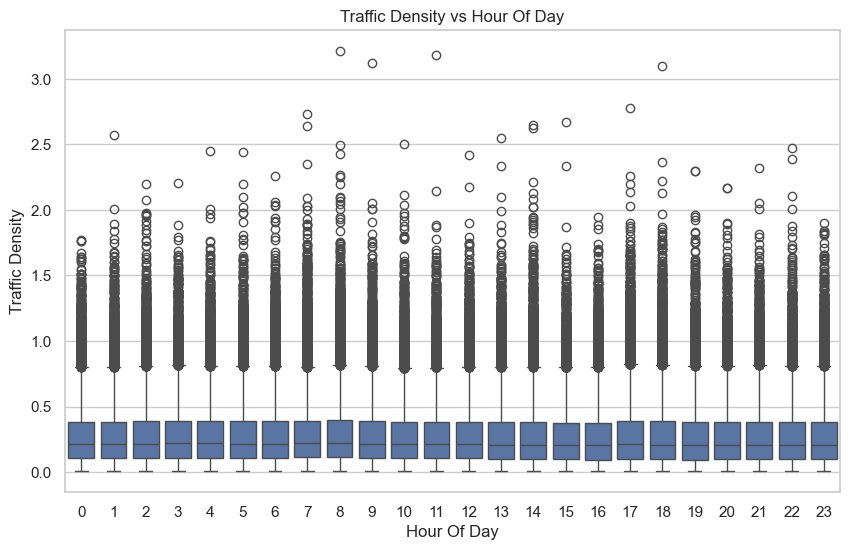

In [115]:
# Traffic Density vs Hour of Day
plt.figure(figsize=(10, 6))
sns.boxplot(x='Hour Of Day', y='Traffic Density', data=traffic)
plt.title('Traffic Density vs Hour Of Day')
plt.show()

C:\Users\VISHWA\AppData\Local\Temp\ipykernel_9728\802748427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_count.index, y=vehicle_count.values, palette='viridis')


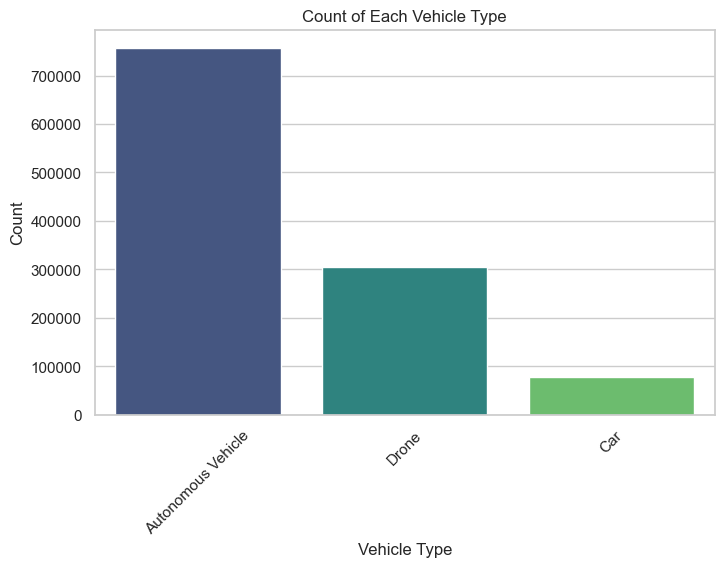

In [119]:
# Visualization of Vehicle Type Counts
plt.figure(figsize=(8, 5))
sns.barplot(x=vehicle_count.index, y=vehicle_count.values, palette='viridis')
plt.title('Count of Each Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

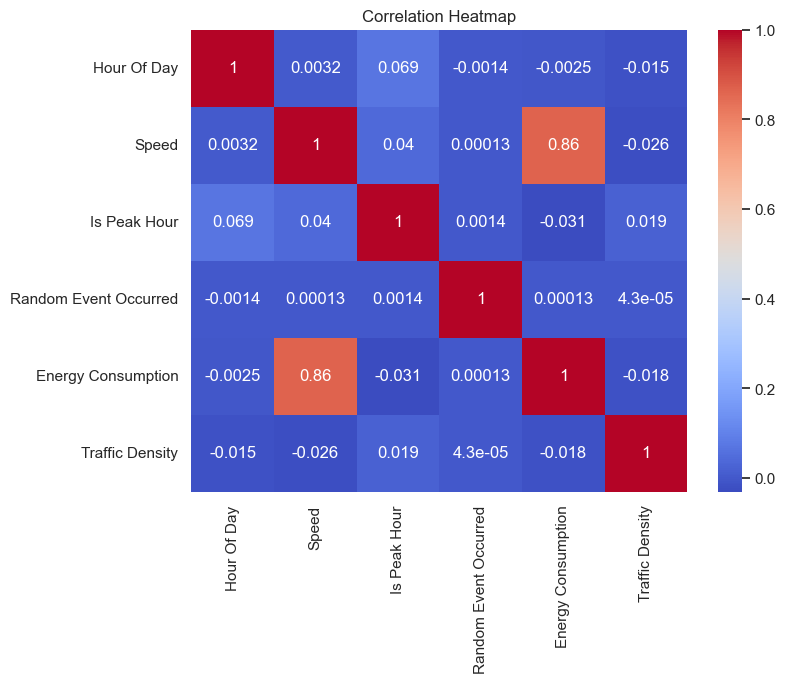

In [121]:
numeric_df = traffic.select_dtypes(include=[np.number])  # Select only numeric columns
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

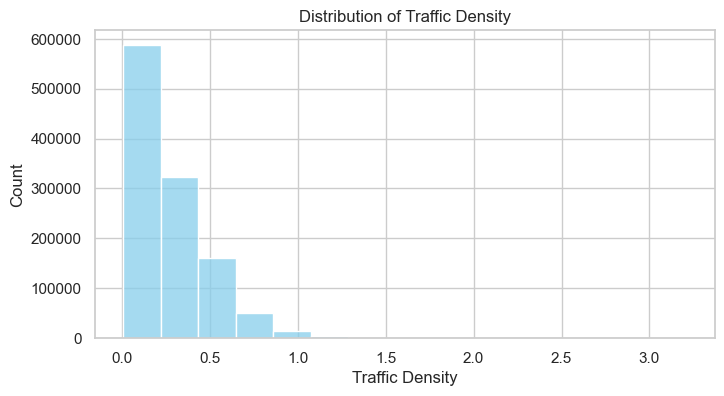

In [123]:
# Visualizations
# Distribution of Traffic Density
# Feature Selection
X = traffic.drop(columns=['Traffic Density'])
y = traffic['Traffic Density']
plt.figure(figsize=(8, 4))
sns.histplot(y, bins=15, color='skyblue')
plt.title('Distribution of Traffic Density')
plt.show()

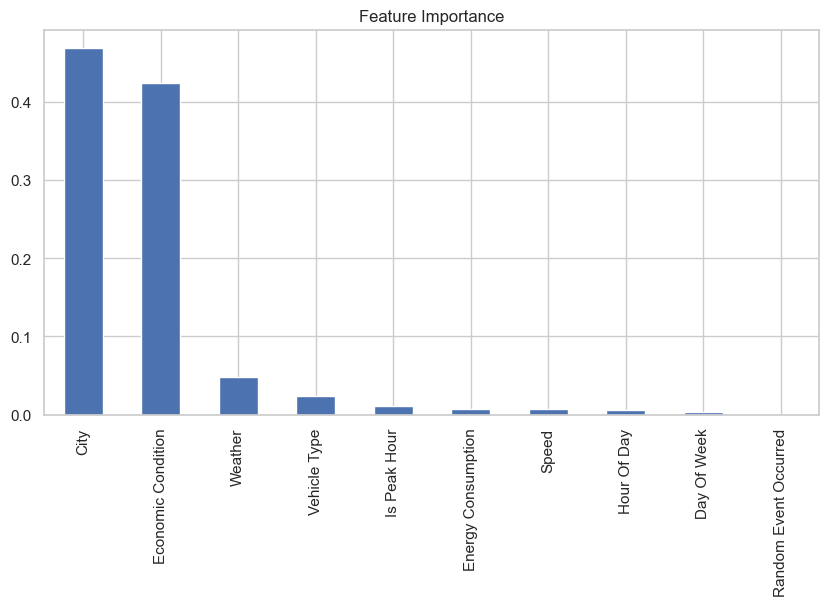

In [124]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), title="Feature Importance")
plt.show()


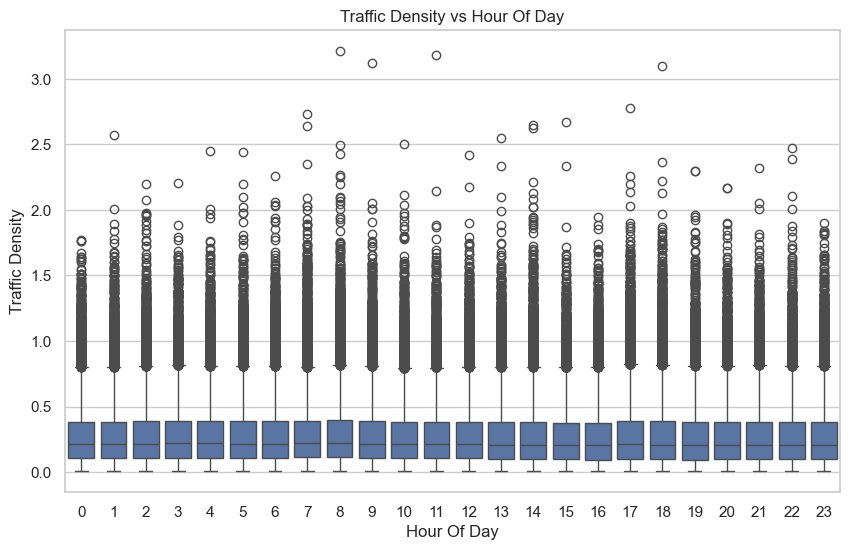

In [127]:
# Traffic Density vs Hour of Day
plt.figure(figsize=(10, 6))
sns.boxplot(x='Hour Of Day', y='Traffic Density', data=traffic)
plt.title('Traffic Density vs Hour Of Day')
plt.show()

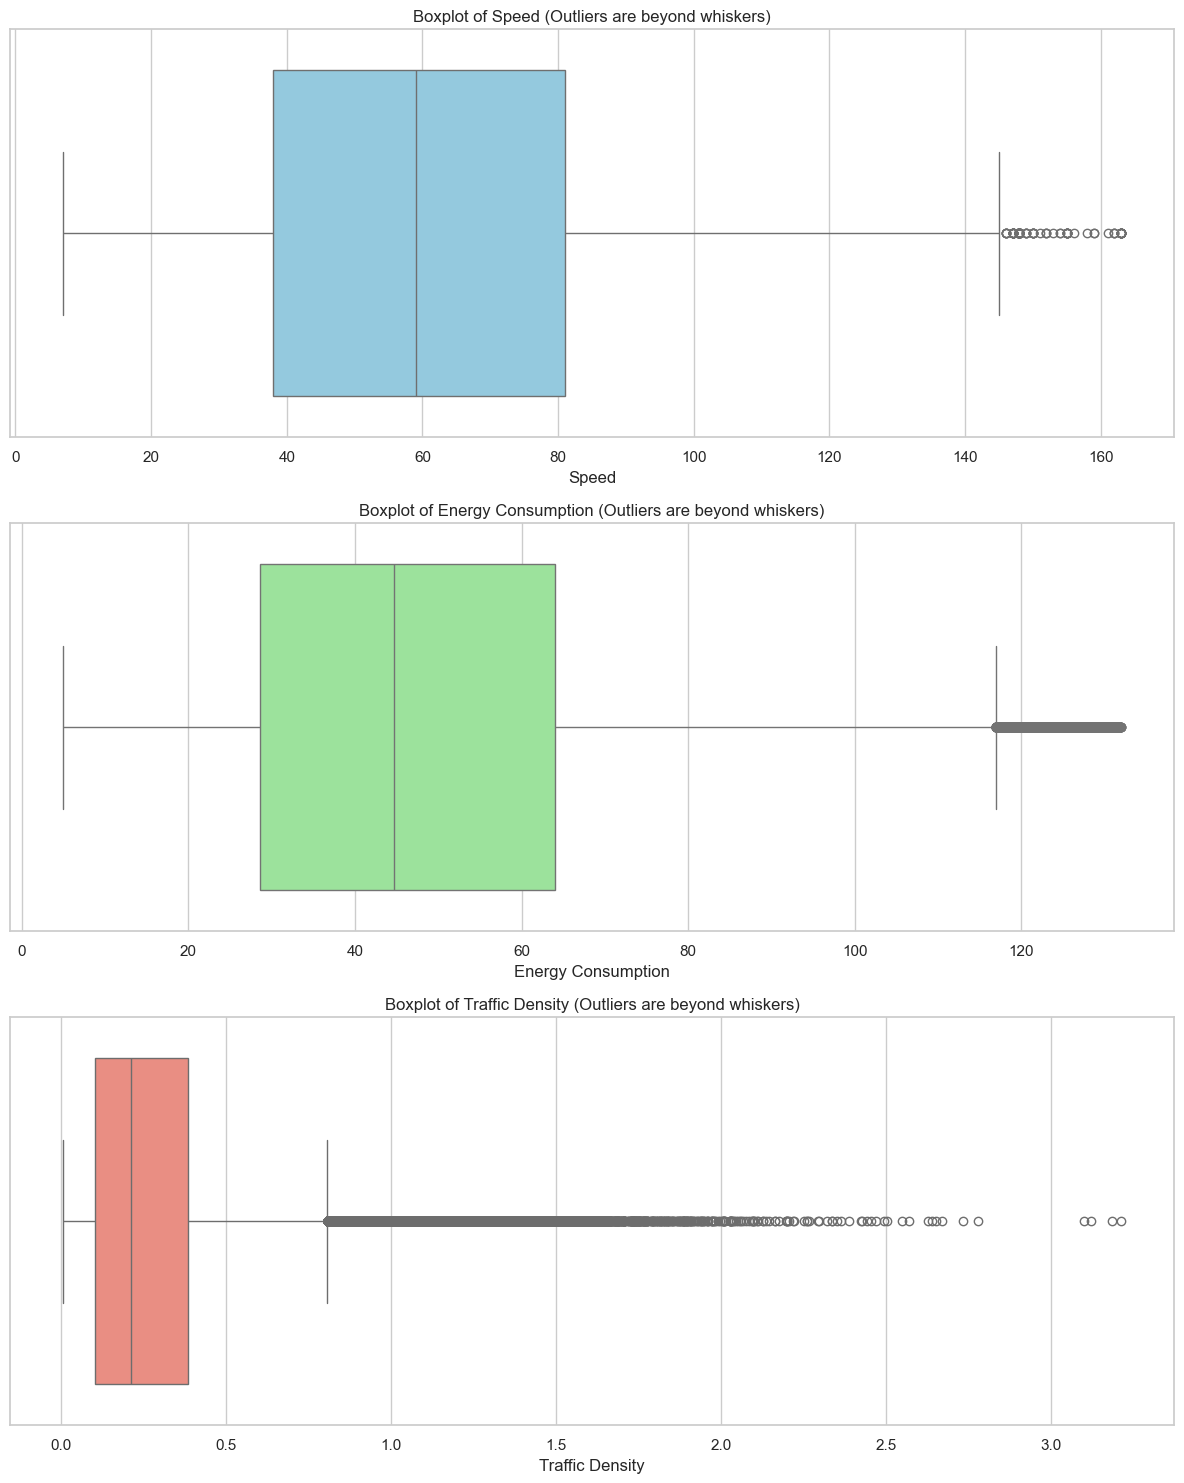

In [129]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Set style for plots
sns.set(style="whitegrid")

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Boxplot for Speed
sns.boxplot(x=traffic['Speed'], ax=axes[0], color="skyblue")
axes[0].set_title('Boxplot of Speed (Outliers are beyond whiskers)')

# Boxplot for Energy Consumption
sns.boxplot(x=traffic['Energy Consumption'], ax=axes[1], color="lightgreen")
axes[1].set_title('Boxplot of Energy Consumption (Outliers are beyond whiskers)')

# Boxplot for Traffic Density
sns.boxplot(x=traffic['Traffic Density'], ax=axes[2], color="salmon")
axes[2].set_title('Boxplot of Traffic Density (Outliers are beyond whiskers)')

plt.tight_layout()
plt.show()


C:\Users\VISHWA\AppData\Local\Temp\ipykernel_9728\2054782668.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour Of Day', y='Traffic Density', data=traffic, palette="coolwarm")


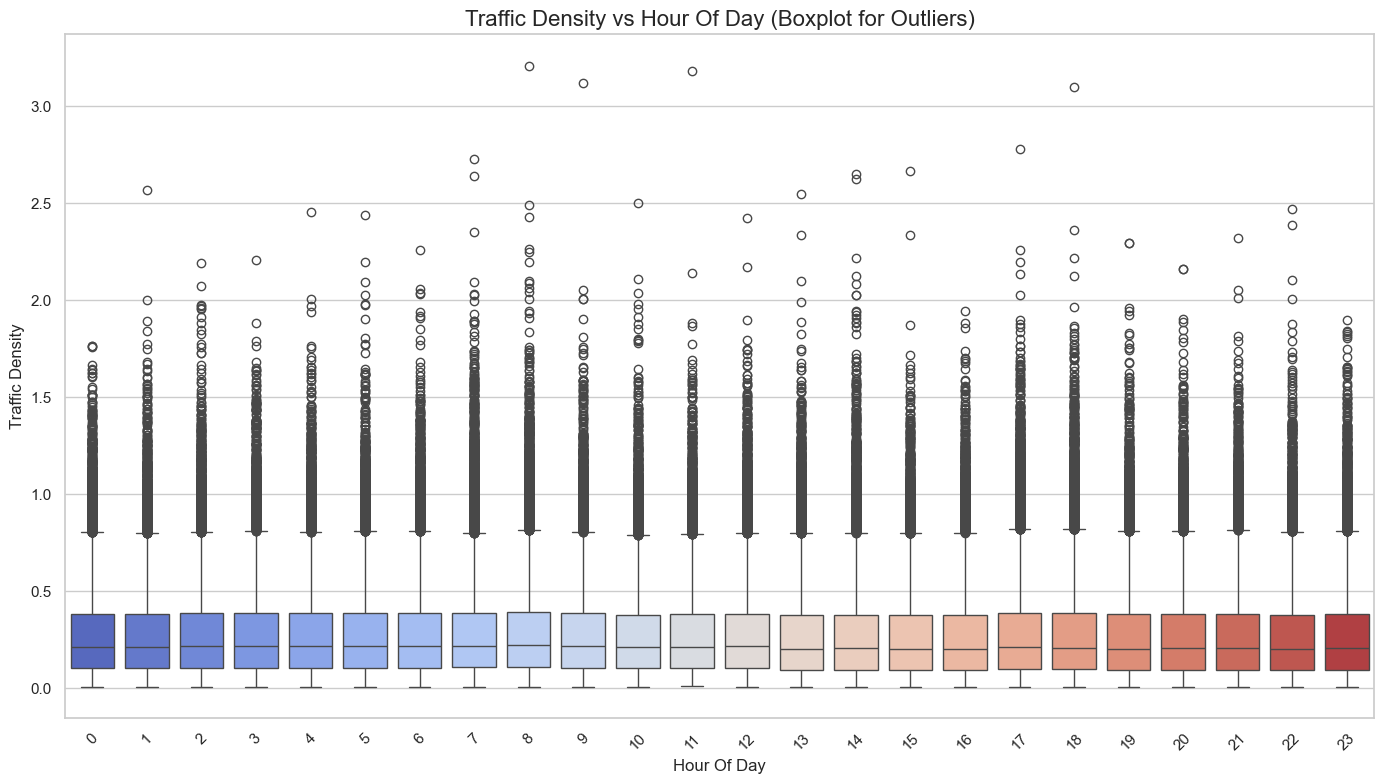

In [131]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style="whitegrid")

# Create a boxplot of Traffic Density by Hour Of Day
plt.figure(figsize=(14, 8))
sns.boxplot(x='Hour Of Day', y='Traffic Density', data=traffic, palette="coolwarm")

plt.title("Traffic Density vs Hour Of Day (Boxplot for Outliers)", fontsize=16)
plt.xlabel("Hour Of Day", fontsize=12)
plt.ylabel("Traffic Density", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [132]:
traffic

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,SolarisVille,Drone,Snowy,Stable,Sunday,20,29.0,0,0,14.7134,0.5241
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday,16,100.0,0,0,91.2640,0.0415
3,Ecoopolis,Drone,Clear,Booming,Thursday,8,77.0,1,0,46.0753,0.1811
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday,16,45.0,0,0,40.1934,0.4544
5,TechHaven,Autonomous Vehicle,Snowy,Recession,Thursday,20,31.0,0,0,37.5562,0.0843
...,...,...,...,...,...,...,...,...,...,...,...
1219562,SolarisVille,Autonomous Vehicle,Electromagnetic Storm,Booming,Wednesday,13,76.0,0,0,60.6027,0.3840
1219563,MetropolisX,Drone,Snowy,Booming,Saturday,1,25.0,0,0,14.8122,0.5526
1219564,Neuroburg,Autonomous Vehicle,Snowy,Booming,Monday,19,76.0,0,0,61.8568,0.0564
1219565,MetropolisX,Autonomous Vehicle,Clear,Booming,Monday,1,53.0,0,0,85.7116,0.5079


In [135]:
traffic

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,SolarisVille,Drone,Snowy,Stable,Sunday,20,29.0,0,0,14.7134,0.5241
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday,16,100.0,0,0,91.2640,0.0415
3,Ecoopolis,Drone,Clear,Booming,Thursday,8,77.0,1,0,46.0753,0.1811
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday,16,45.0,0,0,40.1934,0.4544
5,TechHaven,Autonomous Vehicle,Snowy,Recession,Thursday,20,31.0,0,0,37.5562,0.0843
...,...,...,...,...,...,...,...,...,...,...,...
1219562,SolarisVille,Autonomous Vehicle,Electromagnetic Storm,Booming,Wednesday,13,76.0,0,0,60.6027,0.3840
1219563,MetropolisX,Drone,Snowy,Booming,Saturday,1,25.0,0,0,14.8122,0.5526
1219564,Neuroburg,Autonomous Vehicle,Snowy,Booming,Monday,19,76.0,0,0,61.8568,0.0564
1219565,MetropolisX,Autonomous Vehicle,Clear,Booming,Monday,1,53.0,0,0,85.7116,0.5079


In [137]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Encode categorical features
categorical_cols = ['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    traffic[col] = le.fit_transform(traffic[col])
    label_encoders[col] = le

# For reversing the encode categorical features
# for col in categorical_cols:
#   le = label_encoders[col]
#   df[col] = le.inverse_transform(df[col])

# Features and target
X = traffic.drop('Traffic Density', axis=1)
y = traffic['Traffic Density']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


print(y_pred)

[0.30823153 0.20355992 0.07389244 ... 0.59784985 0.12901118 0.6936847 ]


In [139]:
# Evaluate
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error: 0.0107
R² Score: 0.7662


In [141]:
import numpy as np
import pandas as pd

# Assuming df is your DataFrame

# 1. Cyclical Encoding of Hour
traffic['Hour_sin'] = np.sin(2 * np.pi * traffic['Hour Of Day'] / 24)
traffic['Hour_cos'] = np.cos(2 * np.pi * traffic['Hour Of Day'] / 24)

# 2. Interaction Features
traffic['Speed_Density_Interaction'] = traffic['Speed'] * traffic['Traffic Density']

# 3. Energy Efficiency: how much energy per unit speed
traffic['Energy_per_Speed'] = traffic['Energy Consumption'] / (traffic['Speed'] + 0.1)  # add 0.1 to avoid divide-by-zero

# 4. Weekend Feature
# Assuming 5 = Saturday, 6 = Sunday
traffic['Is_Weekend'] = traffic['Day Of Week'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)

# 5. Rush Hour Flag (custom: 7-9 AM or 4-6 PM)
traffic['Is_Rush_Hour'] = traffic['Hour Of Day'].apply(lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 18) else 0)


In [143]:
traffic

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density,Hour_sin,Hour_cos,Speed_Density_Interaction,Energy_per_Speed,Is_Weekend,Is_Rush_Hour
0,4,2,3,2,3,20,29.0,0,0,14.7134,0.5241,-0.866025,0.500000,15.1989,0.505615,0,0
2,3,0,4,1,6,16,100.0,0,0,91.2640,0.0415,-0.866025,-0.500000,4.1500,0.911728,0,1
3,1,2,0,0,4,8,77.0,1,0,46.0753,0.1811,0.866025,-0.500000,13.9447,0.597604,0,1
4,0,0,4,2,2,16,45.0,0,0,40.1934,0.4544,-0.866025,-0.500000,20.4480,0.891206,0,1
5,5,0,3,1,4,20,31.0,0,0,37.5562,0.0843,-0.866025,0.500000,2.6133,1.207595,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1219562,4,0,1,0,6,13,76.0,0,0,60.6027,0.3840,-0.258819,-0.965926,29.1840,0.796356,0,0
1219563,2,2,3,0,2,1,25.0,0,0,14.8122,0.5526,0.258819,0.965926,13.8150,0.590127,0,0
1219564,3,0,3,0,1,19,76.0,0,0,61.8568,0.0564,-0.965926,0.258819,4.2864,0.812836,0,0
1219565,2,0,0,0,1,1,53.0,0,0,85.7116,0.5079,0.258819,0.965926,26.9187,1.614154,0,0


In [145]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Encode categorical features
categorical_cols = ['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    traffic[col] = le.fit_transform(traffic[col])
    label_encoders[col] = le

# For reversing the encode categorical features
# for col in categorical_cols:
#   le = label_encoders[col]
#   df[col] = le.inverse_transform(df[col])

# Features and target
X = traffic.drop('Traffic Density', axis=1)
y = traffic['Traffic Density']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model_xg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model_xg.fit(X_train, y_train)

# Predict
y_pred = model_xg.predict(X_test)


print(y_pred)

[0.44528714 0.14296317 0.0690492  ... 0.37832072 0.10455859 1.0055583 ]


In [147]:
# Evaluate
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error: 0.0001
R² Score: 0.9979


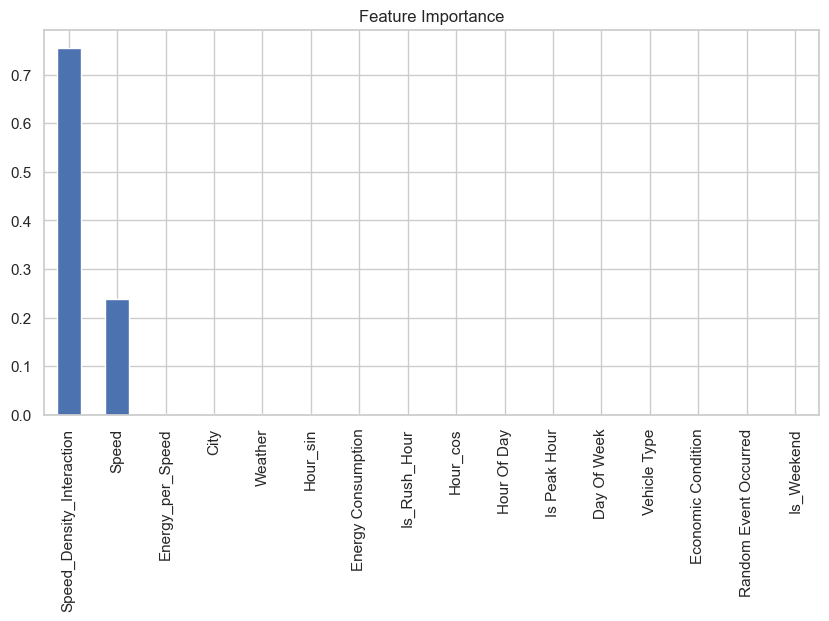

In [149]:
feature_importance = pd.Series(model_xg.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), title="Feature Importance")
plt.show()


# ML perception model

In [154]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=50)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)


In [156]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Feature scaling - important for MLP!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = y  # Target is already numeric and usually doesn't need scaling

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# 3. Define the MLP model
mlp = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam', 
                   max_iter=500, random_state=42, early_stopping=True)

# 4. Train the model
mlp.fit(X_train, y_train)

# 5. Predict
y_pred = mlp.predict(X_test)

# 6. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("🔍 Multilayer Perceptron Performance:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")


🔍 Multilayer Perceptron Performance:
Mean Absolute Error (MAE): 0.0012
R² Score: 0.9999


In [158]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame with same column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

# Train the model on the DataFrame with column names
mlp = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam', 
                   max_iter=500, random_state=42, early_stopping=True)
mlp.fit(X_train, y_train)


MLPRegressor(early_stopping=True, hidden_layer_sizes=(128, 64, 32),
             max_iter=500, random_state=42)

Permutation-based Feature Importance:
Speed_Density_Interaction    4.871546e+00
Speed                        7.870513e-01
Energy Consumption           7.110751e-02
Energy_per_Speed             1.673561e-02
Hour_cos                     3.904123e-05
Hour Of Day                  3.672466e-05
Hour_sin                     1.715760e-05
Vehicle Type                 7.697540e-06
Is_Rush_Hour                 5.912448e-06
Is Peak Hour                 2.941677e-06
City                         1.770379e-06
Day Of Week                  2.743278e-07
Random Event Occurred        1.142136e-07
Is_Weekend                   0.000000e+00
Economic Condition          -2.079070e-07
Weather                     -4.438864e-07
dtype: float64


C:\Users\VISHWA\AppData\Local\Temp\ipykernel_9728\228338298.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, legend=False, palette="plasma")


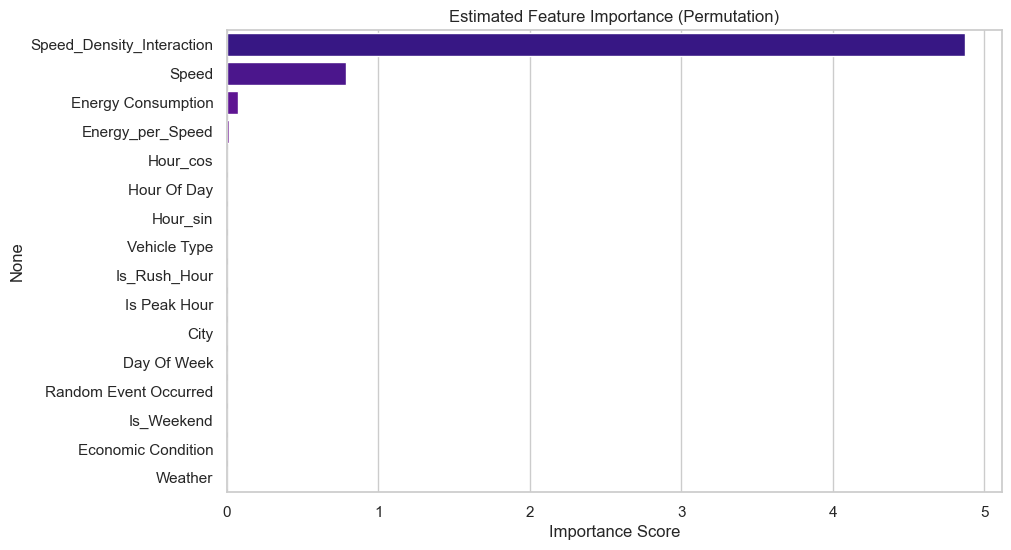

In [164]:
from sklearn.inspection import permutation_importance
import pandas as pd  # make sure this is imported

result = permutation_importance(mlp, X_test, y_test, n_repeats=10, random_state=42)

# 🔧 Corrected line
importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

print("Permutation-based Feature Importance:")
print(importances)

# Optional: Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, legend=False, palette="plasma")
plt.title("Estimated Feature Importance (Permutation)")
plt.xlabel("Importance Score")
plt.show()
